In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from disk_analyzer.stages.model_scoring import ModelScorer

In [4]:
class Model:
    def get_expected_time_by_predictions(self, X_pred, times):
        return np.trapz(X_pred.iloc[:, 2:].values, times)

scores = []
for MAX_TIME in [100, 200, 300, 600]:
    for interv in [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]:
        X_gt = pd.read_csv(f'DDH_gt_{interv}.csv').iloc[:, 1:]
        X_pred = pd.read_csv(f'DDH_pred_{interv}.csv').iloc[:, 1:MAX_TIME+3]

        TIMES = np.arange(0, MAX_TIME)
        METRICS_LIST = ["ci", "ibs", "ibs_bal"]

        scorer = ModelScorer()
        score = scorer.get_metrics(Model(), X_pred, X_gt, TIMES, 
                        metrics=METRICS_LIST)
        score["interv"] = interv
        score["max_time"] = MAX_TIME
        scores.append(score)

FileNotFoundError: [Errno 2] No such file or directory: 'DDH_pred_5.csv'

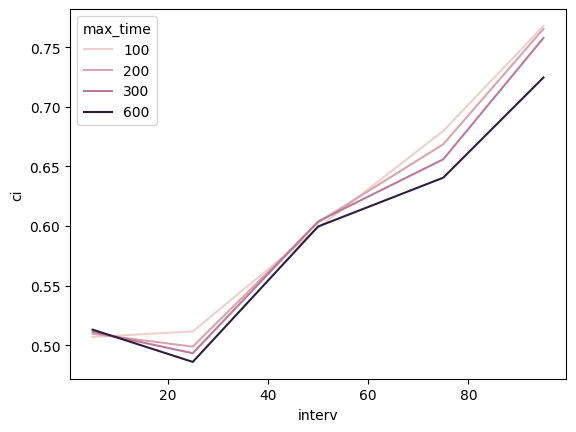

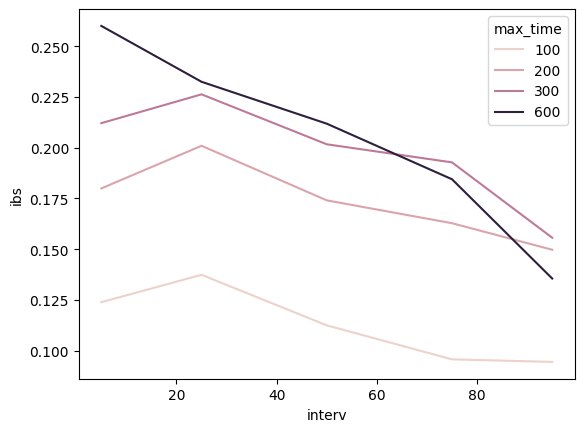

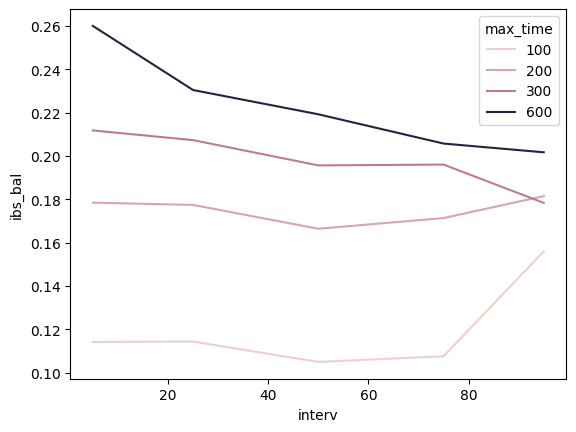

In [ ]:
df_sc = pd.DataFrame(scores)
sns.lineplot(x="interv", y="ci", hue="max_time", data=df_sc)
plt.show()
sns.lineplot(x="interv", y="ibs", hue="max_time", data=df_sc)
plt.show()
sns.lineplot(x="interv", y="ibs_bal", hue="max_time", data=df_sc)
plt.show()

### Mini-EDA

In [ ]:
X_gt_5 = pd.read_csv('DDH_gt_5.csv').iloc[:, 1:]
X_gt_25 = pd.read_csv('DDH_gt_25.csv').iloc[:, 1:]
X_gt_75 = pd.read_csv('DDH_gt_75.csv').iloc[:, 1:]

X_pred_5 = pd.read_csv('DDH_pred_5.csv').iloc[:, 1:]
X_pred_25 = pd.read_csv('DDH_pred_25.csv').iloc[:, 1:]
X_pred_75 = pd.read_csv('DDH_pred_75.csv').iloc[:, 1:]

In [ ]:
X_gt_5["duration"].describe()

count    986.000000
mean     283.246450
std      170.482776
min        2.000000
25%      137.000000
50%      276.000000
75%      428.750000
max      686.000000
Name: duration, dtype: float64

<Axes: xlabel='duration', ylabel='Density'>

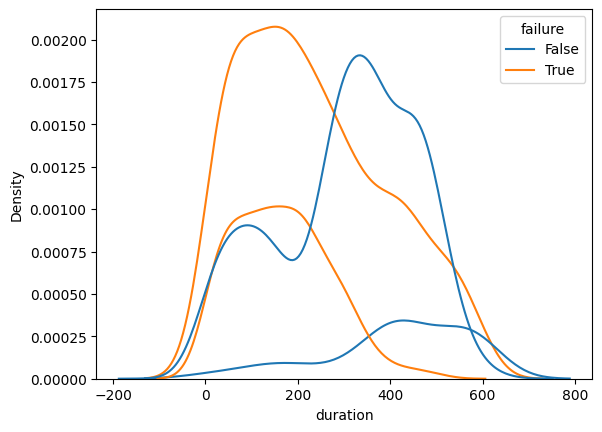

In [ ]:
sns.kdeplot(X_gt_25, x="duration", hue="failure")
sns.kdeplot(X_gt_75, x="duration", hue="failure")

In [ ]:
s1 = X_gt_25.query("duration < 300")["serial_number"] 
s2 = X_gt_5["serial_number"]

s3 = set(s1).intersection(set(s2))

In [ ]:
X_pred_25.query("serial_number in @s3").iloc[3]

serial_number    5732PE2FT
time                  78.0
0                 0.949024
1                 0.949024
2                 0.949024
                   ...    
595               0.246634
596                0.24652
597                0.24652
598                0.24652
599               0.246455
Name: 6, Length: 602, dtype: object

In [ ]:
X_pred_5.query("serial_number in @s3").iloc[3]

serial_number    5732PE2FT
time                 397.0
0                  0.92974
1                  0.92974
2                  0.92974
                   ...    
595               0.342847
596               0.342794
597               0.342794
598               0.342794
599               0.342762
Name: 6, Length: 602, dtype: object

<Axes: xlabel='exp_time', ylabel='duration'>

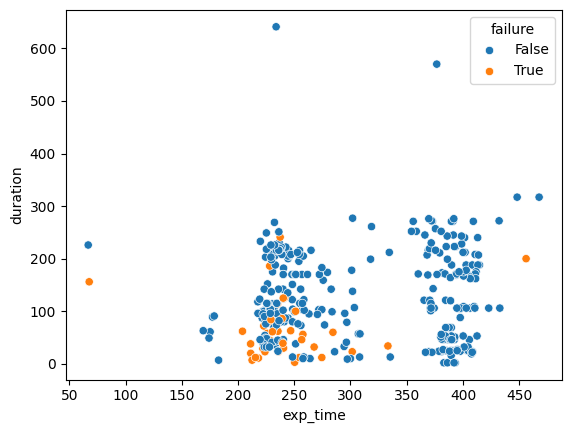

In [ ]:
X_gt["exp_time"] = np.trapz(X_pred.iloc[:, 2:].values, TIMES)
sns.scatterplot(x="exp_time", y="duration", data=X_gt, hue="failure")

In [ ]:
from lifelines.utils import concordance_index
concordance_index(X_gt['duration'], X_gt["exp_time"], X_gt['failure'])

0.48607699334001403